# Starting note
At the time of writing this notebook, I was going through and tried to follow (roughly) Valerio Velardo's `"PyTorch for Audio + Music Processing"` course on Youtube, so I must state that most parts were built inspiring from his thought process.

In [7]:
!hf auth login

? How would you like to log in?  [Use arrows, Enter to confirm]
> Log in with your browser
  Paste an access token
? How would you like to log in? Log in with your browser

    Open this URL in your browser:
        https://hf.co/oauth/device

    And enter the code: 8L09-MCR8

    Waiting for authorization......
Token is valid.
The token `oauth-pop123ux` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `oauth-pop123ux`
Note: This token will be refreshed automatically when it expires.


In [1]:
from datasets import load_dataset
dataset = load_dataset('Micol/musical-instruments-sound-dataset')

README.md:   0%|          | 0.00/970 [00:00<?, ?B/s]

data/train-00000-of-00006.parquet: reconstructing file:   0%|          |  0.00B /  281MB            

data/train-00000-of-00006.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00006.parquet: reconstructing file:   0%|          |  0.00B /  473MB            

data/train-00001-of-00006.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  207MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2103 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/526 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/80 [00:00<?, ? examples/s]

In [3]:
!ls

sample_data


## A note on torchaudio.backend

We are going to use the **torchaudio.backend** module which provides implementations audio file I/O functionalities, which are `torchaudio.info`, `torchaudio.load`, `torchaudio.loadwav` and `torchaudio.save`.

- Since `torchaudio.load()` is written in C++ in the backend and it is programmed to interact with objects that have methods specific to a file: `.read()`, `.seek()`, `.tell()`, we need to turn the raw_bytes into a memory buffer that acts as a file object: `io.BytesIO(audio_bytes)` doesn't copy the data or move it anywhere else. It simply **places a file mask** over those existing bytes, adding the `.read()` and `.seek()` methods that `torchaudio` requires.

- So `io.BytesIO` will act as **the translator** that allows `torchaudio` to understand and decode the raw_byte data directly in memory, without forcing us to physically save it to the disk as a `.wav` file.

**Update**: used alternative `get_all_samples()` torchcodec method for our dataset

In [2]:
import os
import io
import torch
import torchaudio
from torch.utils.data import Dataset
import pandas as pd

class MusicalDatasetV1(Dataset):

  def __init__(self, dsdict, split, audio_dir=None):
    allowed_splits = ['train', 'validation', 'test']
    if split not in allowed_splits:
      raise ValueError(f"Invalid split '{split}'. Expected one of {allowed_splits}")
    self.dataset = dsdict[split]
    if audio_dir:
      self.audio_dir = audio_dir

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    row = self.dataset[idx]

    audio_cell = row['audio']
    label = torch.tensor(row['label'], dtype=torch.long) # torch.long because we have purely classes which are integers

    #audio_bytes = audio_cell['bytes']

    #audio_file_like = io.BytesIO(audio_bytes) # Creates memory buffer (isolated zone in RAM) - "file-like object" | Transform bytes as virtual file stored in memory


    #signal, sr = torchaudio.load(audio_file_like)

    audio_samples = audio_cell.get_all_samples()

    signal = audio_samples.data # Shape [channels, time_steps]

    return signal, label

  """Course methods for processing directly out of a directory - not used inside this class - works only with pandas DataFrames"""
  def _get_audio_sample_path(self, index):
    fold = f"fold{self.dataset.iloc[index, 5]}"
    path = os.path.join(self.audio_dir, self.dataset.iloc[index, 0])
    return path

  def _get_audio_sample_label(self, index):
    return self.dataset.iloc[index, 6]

In [3]:
import wave

df_train = dataset['train']

"""Function to identify the wav file duration statistics"""
def get_wav_length(dataset):

  audio_cell = dataset['audio']
  try:
    samples = audio_cell.get_all_samples() # Decodify the file normally

    num_frames = samples.data.shape[1] # samples.data.shape[1] is the time axis (number of batches)
  except Exception as e:
    num_frames = -1 # Handle buffer errors

  #audio_file_like = io.BytesIO(audio_cell['bytes'])

  #"""Open the file using Python's built-in wave library"""
  #with wave.open(audio_file_like, 'rb') as wav_file:
    #num_frames = wav_file.getnframes()
    #sample_rate = wav_file.getframerate()

  return {"num_frames": num_frames}

meta_dataset = df_train.map(get_wav_length, remove_columns=df_train.column_names)

lengths_series = pd.Series(meta_dataset['num_frames'])

Map:   0%|          | 0/2103 [00:00<?, ? examples/s]

In [4]:
valid_lengths = lengths_series[lengths_series > 0]

In [5]:
print(f"""
Corrupted count -> {lengths_series[lengths_series==-1].sum()}
Minimum length -> {valid_lengths.min()} samples | ~ {valid_lengths.min()/16000} seconds
Maximum length -> {valid_lengths.max()} samples | ~ {valid_lengths.max()/16000} seconds
Average length -> {valid_lengths.mean():.1f} samples | ~ {valid_lengths.mean()//16000} seconds""")


Corrupted count -> -6
Minimum length -> 40320 samples | ~ 2.52 seconds
Maximum length -> 3616200 samples | ~ 226.0125 seconds
Average length -> 746909.9 samples | ~ 46.0 seconds


### Key Observation:
- The dataset contains a **highly diverse range of durations** as we can observe from above.

- Padding all arrays to match the max length of `4 minutes (226 seconds)` would waste a massive amount of VRAM and slow down the future model. Alternatively, truncating to 2 seconds throws away crucial information.

So, setting a balanced **fixed target length** inside the dataset would be best practice for audio classification

In [15]:
import os
import io
import torch
import torchaudio
from torch.utils.data import Dataset
import torch.nn as nn
import pandas as pd

class MusicalDatasetV2(Dataset):

  def __init__(self, dsdict, split, target_length=16000, sample_rate=16000):
    allowed_splits = ['train', 'validation', 'test']
    if split not in allowed_splits:
      raise ValueError(f"Invalid split '{split}'. Expected one of {allowed_splits}")
    self.dataset = dsdict[split]
    self.target_length = target_length

    # Define Mel Spectrogram transformation
    self.mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=1024, # Step size of the window to analyse frequencies
        hop_length=512, # Step size between analysis windows (image width)
        n_mels=64, # Number of Mel frequency bins (image height)
    )

    # Equivalent to librosa.power_to_db() - transforms vanilla spectrogram to log-amplitude spectrogram
    self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    row = self.dataset[idx]

    audio_cell = row['audio']
    label = torch.tensor(row['label'], dtype=torch.long) # torch.long because we have purely classes which are integers
    try:
      # Decode the compressed clip directly through the backend object layer
      audio_samples = audio_cell.get_all_samples()
      signal = audio_samples.data # Shape [channels, time_steps] | Obs: channels=1 for mono; channels=2 for stereo

      # Fix stereo to mono - if channels > 1, average them into 1 single channel
      if signal.shape[0] > 1:
        signal = torch.mean(signal, dim=0, keepdim=True)

      # Cut down any audio vectors that exceed the standard footprint
      if signal.shape[1] > self.target_length:
        signal = signal[:, :self.target_length]

      # Pad shorter sequences sequences with zero matrices on the time axis
      elif signal.shape[1] < self.target_length:
        pad_amount = self.target_length - signal.shape[1]
        # Pad only the trailing end of the last dimension (time_steps)
        signal = torch.nn.functional.pad(signal, (0, pad_amount), mode='constant', value=0.0) # Adds zeros to the right side of the final dimension | (0, pad_amount) means (pad_left, pad_right), so we add 0 zeros to the front, and 2 zeros to the back

    except Exception as e:
      # Fall back to a dummy zero-tensor if the track is corrupt
      # Skips over corrupt entries cleanly without aborting execution mid-training
      signal = torch.zeros((1, self.target_length), dtype=torch.float32)


    mel_spec = self.amplitude_to_db(self.mel_transform(signal))

    return mel_spec, label # mel_spec shape [C, frequency, time_axis]


In [16]:
train_df = MusicalDatasetV2(dsdict=dataset, split='train')
test_df = MusicalDatasetV2(dsdict=dataset, split='test')
val_df = MusicalDatasetV2(dsdict=dataset, split='validation')

In [17]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_df, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_df, batch_size=32, num_workers=0)
val_loader = DataLoader(val_df, batch_size=1, num_workers=0)

Signal batch shape: torch.Size([32, 1, 64, 32])
Labels batch shape: torch.Size([32])


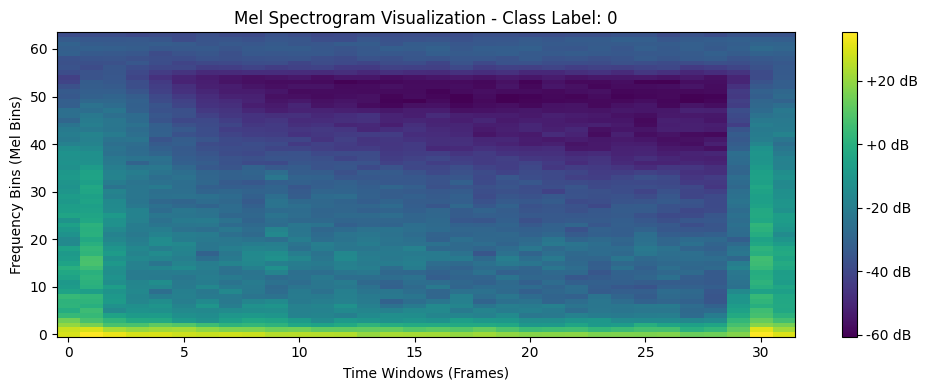

In [37]:
import matplotlib.pyplot as plt

"""Visualizing one batch of the train loader we created"""
signals_batch, labels_batch = next(iter(train_loader))

print(f"Signal batch shape: {signals_batch.shape}")
print(f"Labels batch shape: {labels_batch.shape}")

# .squeeze() to remove the 1-channel dimension
single_spectrogram = signals_batch[0].squeeze()
single_label = labels_batch[0].item()

plt.figure(figsize=(10,4))

plt.imshow(single_spectrogram.numpy(), aspect='auto', origin='lower', cmap='viridis')
plt.title(f"Mel Spectrogram Visualization - Class Label: {single_label}")
plt.ylabel("Frequency Bins (Mel Bins)")
plt.xlabel("Time Windows (Frames)")
plt.colorbar(format="%+2.0f dB") # Shows the loudness scale in decibels

plt.tight_layout()
plt.show()


In [22]:
signals_batch[0].squeeze().shape

torch.Size([32, 64, 32])

In [24]:
labels_batch[0].item()

3

In [27]:
single_spectrogram = signals_batch[0].squeeze()
type(single_spectrogram.numpy())

numpy.ndarray

In [51]:
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [60]:
model = models.resnet18(pretrained=True)
model.conv1

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

In [97]:
!pip install librosa

In [106]:
"""CNN for audio classification"""
import torchvision.models as models
import numpy as np
import librosa
from IPython.display import Audio, display

class AudioCNN(nn.Module):
  def __init__(self, num_classes=4):
    super().__init__()
    self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    self.model.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=7, stride=2, padding=3, bias=False)
    in_features = self.model.fc.in_features # 1024
    self.model.fc = nn.Linear(in_features, num_classes)


  def _loader_pass(self, loader):
    if not isinstance(loader, DataLoader): # Verification
        raise ValueError(
            f"Please select a valid loader instance. "
            f"Expected torch.utils.data.DataLoader, but got {type(loader).__name__}"
        )

  def fit(self, loader, criterion=torch.nn.CrossEntropyLoss(), use_scheduler=False, EPOCHS=5):
    if not isinstance(loader, DataLoader): # Verification
        raise ValueError(
            f"Please select a valid loader instance. "
            f"Expected torch.utils.data.DataLoader, but got {type(loader).__name__}"
        )
    self.model.train()
    loss_l = []
    criterion = criterion
    optim = torch.optim.AdamW(params=self.model.parameters(), lr=0.01)
    if use_scheduler:
      scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
          optim,
          T_max=EPOCHS, # the T_max parameter tells the scheduler in steps in how much time to lower the learning rate from the initial value to the value established by eta_min
          eta_min=0.0001
      )

    # Training
    for epoch in range(EPOCHS):
      current_loss=0.
      last_loss=0.
      for idx, data in enumerate(loader):
        images, labels = data

        optim.zero_grad()

        outputs = self.model(images)

        loss = criterion(outputs, labels)
        loss.backward()

        optim.step()

        current_loss += loss.item()

      if use_scheduler:
          scheduler.step()

      epoch_loss = current_loss / len(loader)
      loss_l.append(epoch_loss)

      print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f}")

  def val(self, loader, criterion=torch.nn.CrossEntropyLoss(), return_y_preds=False):
    if not isinstance(loader, DataLoader): # Verification
        raise ValueError(
            f"Please select a valid loader instance. "
            f"Expected torch.utils.data.DataLoader, but got {type(loader).__name__}"
        )
    self.model.eval()
    y_preds_list = []
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
      for idx, data in enumerate(loader):
        images, labels = data

        outputs = self.model(images)
        y_preds_list.append(outputs.cpu().numpy())

        loss = criterion(outputs, labels)

        val_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = val_loss / len(loader) # len(loader) is the number of batches in the validation dataset; if we have 400 images in total with a batch size of 4, len(loader) = 400/4 = 100
    accuracy = (correct / total) * 100 if total > 0 else 0

    if return_y_preds:
      return avg_loss, accuracy, np.vstack(y_preds_list)

    return avg_loss, accuracy, _

  def plot_batch(self, loader, num=5):
    self._loader_pass(loader=loader)
    if loader.batch_size < num:
      raise ValueError(f"Current batch size is {loader.batch_size}, and you called the function on {num} numbers")

    sr = 16000
    n_fft = 1024
    n_mels = 64

    inverse_mel = torchaudio.transforms.InverseMelScale(sample_rate=sr, n_stft=n_fft // 2 + 1, n_mels=n_mels)
    griffin_lim = torchaudio.transforms.GriffinLim(n_fft=n_fft)

    signals_batch, labels_batch = next(iter(loader))

    for i in range(num):
      img = signals_batch[i].squeeze() # Shape [B, Freq, Nr_frames]
      label = labels_batch[i]
      plt.imshow(img, cmap='Blues')
      plt.ylabel("Mel Bins")
      plt.xlabel("Frames")
      plt.colorbar()
      plt.show()
      print(f"Label: {label}")

      try:
        spec_power = img.cpu() # tensor to cpu

        lin_spectrogram = inverse_mel(spec_power) # Mel -> Linear STFT -> Waveform
        waveform = griffin_lim(lin_spectrogram)

        """Display play button"""
        display(Audio(waveform.numpy(), rate=sr))

      except Exception as e:
        print(f"Could not reconstruct audio: {e}")

      print("-" * 50)


In [ ]:
signals_batch, labels_batch = next(iter(train_loader))
labels_batch

In [107]:
model = AudioCNN()

In [80]:
model.fit(loader=train_loader, EPOCHS=20, use_scheduler=True)

Epoch 1/20 - Loss: 2.2037
Epoch 2/20 - Loss: 1.3380
Epoch 3/20 - Loss: 1.2122
Epoch 4/20 - Loss: 1.1145
Epoch 5/20 - Loss: 1.0316
Epoch 6/20 - Loss: 0.9699
Epoch 7/20 - Loss: 0.9257
Epoch 8/20 - Loss: 0.8965
Epoch 9/20 - Loss: 0.9341
Epoch 10/20 - Loss: 0.8507
Epoch 11/20 - Loss: 0.8432
Epoch 12/20 - Loss: 0.8073
Epoch 13/20 - Loss: 0.8014
Epoch 14/20 - Loss: 0.7913
Epoch 15/20 - Loss: 0.7758
Epoch 16/20 - Loss: 0.7958
Epoch 17/20 - Loss: 0.7910
Epoch 18/20 - Loss: 0.7653
Epoch 19/20 - Loss: 0.7569
Epoch 20/20 - Loss: 0.7559


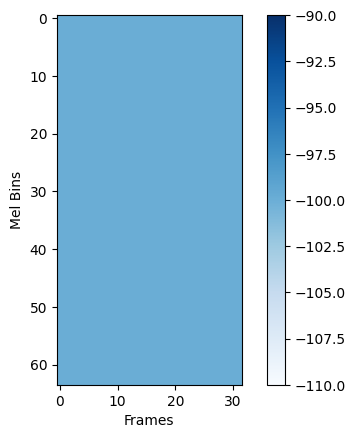

Label: 1


--------------------------------------------------


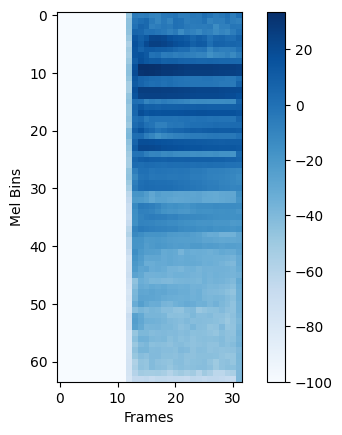

Label: 2


--------------------------------------------------


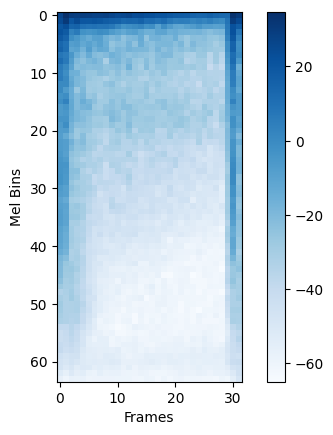

Label: 3


--------------------------------------------------


In [108]:
model.plot_batch(num=3, loader=train_loader)

In [83]:
avg_loss, accuracy, y_preds_list = model.val(loader=val_loader, return_y_preds=True)

In [84]:
avg_loss, accuracy, y_preds_list

(0.7615447055500676,
 56.083650190114064,
 array([[ 2.6538904, -5.6243625, -2.1141732,  2.6720543],
        [ 1.071203 , -4.3767533,  1.3003349,  1.1626043],
        [ 2.400568 , -4.7801995, -2.367952 ,  2.480928 ],
        ...,
        [ 2.8963852, -5.7183075, -2.666504 ,  2.8433042],
        [ 1.1800115, -3.8990564,  0.3903596,  1.2877792],
        [ 2.8006263, -5.5208426, -2.8406415,  2.8171315]], dtype=float32))